In [63]:
"""
Module: main_TSC_LS.ipynb
Author: Dema N. Govalla
Date: December 4, 2023
Description: The file trains and test the combined_sensorData.csv file using the RFMN algorithm. 
            After traning and testing, it returns the algorithms metrics such as accuracy, presision and more.
            The file performs cross validation for different RFMN parameters and returns the classification
            report.  
"""

import sys, statistics, numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt, os
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, fbeta_score, matthews_corrcoef
from sklearn.utils.multiclass import unique_labels
from RFMN import ReflexFuzzyNeuroNetwork

# np.set_printoptions(threshold=5)
# np.set_printoptions(threshold=np.inf)


In [64]:
sensor_data = pd.read_csv('combined_sensorData.csv')
sensor_data = sensor_data.iloc[:,0:]
sensor_data.head()

,ave_filt_force,ave_filt_xaxis,ave_filt_yaxis,ave_filt_zaxis,med_filt_force,med_filt_xaxis,med_filt_yaxis,med_filt_zaxis,Class
0,-0.06,-72.51,419.79,-2507.16,0.0,-72.0,420.0,-2506.5,1
1,-0.06,-72.36,419.76,-2507.16,0.0,-72.0,420.0,-2506.5,1
2,-0.06,-72.30,419.82,-2507.16,0.0,-72.0,420.0,-2506.5,1
3,-0.08,-72.27,419.79,-2507.16,0.0,-72.0,420.0,-2506.5,1
4,-0.10,-72.21,419.82,-2507.13,0.0,-72.0,420.0,-2506.5,1


In [61]:
# separate the independent and dependent features
X = sensor_data.iloc[:, :-1].values
y = sensor_data.iloc[:, 8].values

scaler_min_max = MinMaxScaler(feature_range=(0.001, .99))
X_norm = scaler_min_max.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split( X_norm, y, test_size=0.33, random_state=42)
X_train, X_test = X_train.T, X_test.T
y_train, y_test = y_train.T, y_test.T

nn = ReflexFuzzyNeuroNetwork(gamma=5, theta=.5)
nn.train(X_train, y_train)
print("Model is trained")

Model is trained


In [62]:
y_predlr = nn.test(X_test,y_test)
print("done with predictions")

KeyboardInterrupt: 

In [ ]:
print("confusion_matrix \n", confusion_matrix(y_test, y_predlr), "\n")
print("classification_report \n", classification_report(y_test, y_predlr), "\n")
     

confusion_matrix 
 [[1298    0    0    0]
 [  24 1258   21   12]
 [  16   91  828  385]
 [   0   12  150 1121]] 

classification_report 
               precision    recall  f1-score   support

           1       0.97      1.00      0.98      1298
           2       0.92      0.96      0.94      1315
           3       0.83      0.63      0.71      1320
           4       0.74      0.87      0.80      1283

    accuracy                           0.86      5216
   macro avg       0.87      0.86      0.86      5216
weighted avg       0.87      0.86      0.86      5216
 



In [ ]:
unique_labels(y_test)

def plot(y_true, y_pred):
    labels = unique_labels(y_test)
    column = [f'Predicted {label}' for label in labels]
    indices = [f'Actual {label}' for label in labels]
    table = pd.DataFrame(confusion_matrix(y_true, y_pred), columns = column, index=indices)
    return table
plot(y_test, y_predlr)

,Predicted 1,Predicted 2,Predicted 3,Predicted 4
Actual 1,1298,0,0,0
Actual 2,24,1258,21,12
Actual 3,16,91,828,385
Actual 4,0,12,150,1121


0.8636886503067485


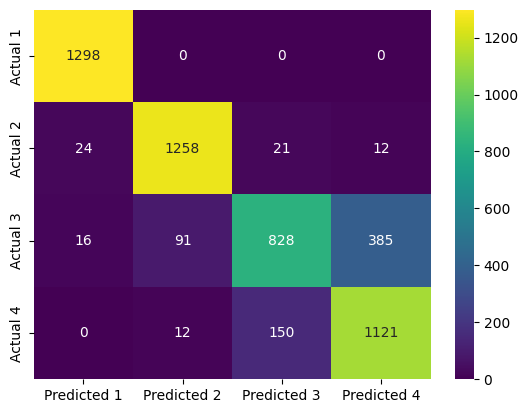

In [ ]:
def plot2(y_true, y_pred):
    labels = unique_labels(y_test)
    column = [f'Predicted {label}' for label in labels]
    indices = [f'Actual {label}' for label in labels]
    table = pd.DataFrame(confusion_matrix(y_true, y_pred), columns = column, index=indices)
    return sns.heatmap(table, annot = True, fmt = 'd', cmap= 'viridis')
plot2(y_test, y_predlr)

accuracy_score1 = accuracy_score(y_test, y_predlr)
print(accuracy_score1)


In [ ]:
'''
Start of Cross validation results
'''

# initialise a StratifiedKFold object with 5 folds and
# declare the column that we which to group by which in this
# case is the column called "label"
n_splits=10
skf = StratifiedKFold(n_splits=n_splits, shuffle= True, random_state=42)

target = sensor_data.loc[:,'Class']



In [ ]:

# Define the directory path
directory_path = 'C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\Tactile-Feedback-Repo\\cross_val_RFMN_hardness'

# Check if the directory exists, create it if it doesn't
if not os.path.exists(directory_path):
    os.makedirs(directory_path)

# for each fold split the data into train and validation 
# sets and save the fold splits to csv
fold_no = 1
for train_index, val_index in skf.split(sensor_data, target):
    train = sensor_data.loc[train_index,:]
    val = sensor_data.loc[val_index,:]

    # Now you can save the files to this directory
    train.to_csv(os.path.join(directory_path, 'train_fold_' + str(fold_no) + '.csv'))
    val.to_csv(os.path.join(directory_path, 'val_fold_' + str(fold_no) + '.csv'))
    fold_no += 1



In [ ]:
count = 1
accuracy_array = []
count_array = []
for fold_no in range(1,n_splits+1):

    newtrain = pd.read_csv(os.path.join(directory_path, 'train_fold_' + str(fold_no) + '.csv'))
    newval = pd.read_csv(os.path.join(directory_path, 'val_fold_' + str(fold_no) + '.csv'))

    newtrain = newtrain.iloc[:,1:]
    newval = newval.iloc[:,1:]

    new_X_train = newtrain.iloc[:,:-1]
    new_y_train = newtrain.iloc[:,-1]

    new_X_val = newval.iloc[:,:-1]
    new_y_val = newval.iloc[:,-1] 

    scaler_min_max = MinMaxScaler(feature_range=(0.01, .99))
    new_X_train = scaler_min_max.fit_transform(new_X_train)
    new_X_val = scaler_min_max.fit_transform(new_X_val)

    # new_y_train, new_y_val = new_y_train.values, new_y_val.values 
    # new_y_train, new_y_val = new_y_train.T, new_y_val.T
    new_X_train, new_X_val = new_X_train.T, new_X_val.T 

    nn_val = ReflexFuzzyNeuroNetwork(gamma=5, theta=.5)
    nn_val.train(new_X_train, new_y_train)
    print("Training is Done")

    y_predlr_val = nn_val.test(new_X_val,new_y_val)

    # check results
    print("confusion_matrix for count \n", confusion_matrix(new_y_val, y_predlr_val), "\n")
    print("classification_report for count \n", classification_report(new_y_val,y_predlr_val), "\n")

    np.set_printoptions(threshold=sys.maxsize)
    unique_labels(new_y_val)

    plot(new_y_val, y_predlr_val)
    # plot2(new_y_val, y_predlr_val)

    accuracy_score1 = accuracy_score(new_y_val, y_predlr_val)
    accuracy_array.append(accuracy_score1)
    count_array.append(count)
    count +=1


113784
12648
(14223, 8)
(1581, 8)
113784
12648
(8, 14223)
(8, 1581)
Training is Done


KeyboardInterrupt: 

In [ ]:
print("Accuracy out of loop: ", accuracy_array)
print("Count out of loop: ", count_array)
print("std", statistics.stdev(accuracy_array))
print("mean", statistics.mean(accuracy_array))

df = pd.DataFrame({
      'data': accuracy_array,
      'mean': [statistics.mean(accuracy_array) for i in range(1, len(accuracy_array)+1, 1)],
      'std': [statistics.stdev(accuracy_array) for i in range(1, len(accuracy_array)+1, 1)]})

df.plot()
plt.show()

In [ ]:
# '''
# Using the pickle library/ pickle file to save the ML model
# '''
# import pickle 

# # save the iris classification model as a pickle file
# model_pk1_file = "iris_RFMN_model.pkl"

# with open(model_pk1_file, 'wb') as file:
#     pickle.dump(nn, file)

    

In [ ]:
# # load model from pickle file
# with open(model_pk1_file, "rb") as file: 
#     model = pickle.load(file)

# # --- Test Network --- #
# y_predict = nn.test(X_test,y_test)

# print("done with predictions")

# # check results
# print(classification_report(y_test, y_predict))